# Import the Data

In this section we import the data from the website and csv files and put it in two dataframes. `df_image` contains information about what we can see on the cartoon. `df_caption` contains the captions provided by the public and how many votes they got. 

In [2]:
#import all the packages

import sys, os
sys.path.append(os.path.abspath("src"))

from src.utils.utils_import import *

# Creation of dataframes and preprocessing

In [3]:
df_image = get_image_data()
df_caption = get_caption_dataset(df_image)

save_to_csv(df_image, 'data/newyorker_caption_contest/df_complete.csv')

In [3]:
df_caption.head(5)

,contest_id,date,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny
0,510,2016-03-07,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18
1,510,2016-03-07,1,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5
2,510,2016-03-07,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8
3,510,2016-03-07,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3
4,510,2016-03-07,4,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6


In [4]:
df_image.head(5)

,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198


# Analysis of the contest dataset's captions

This section present a detailed exploration of the relationships between word mentions in captions. The analysis investigates how words specific to a political or global event appear in image captions over time.

Additionally, a Bechdel-like test was done to analyze the times wordgroups for women compared with those fore men mentioned. This is further analyzed for an interaction analysis


First, we took 50 captions of each contest cartoon with the highest ranks to check what words are the most frequent in the captions in general.

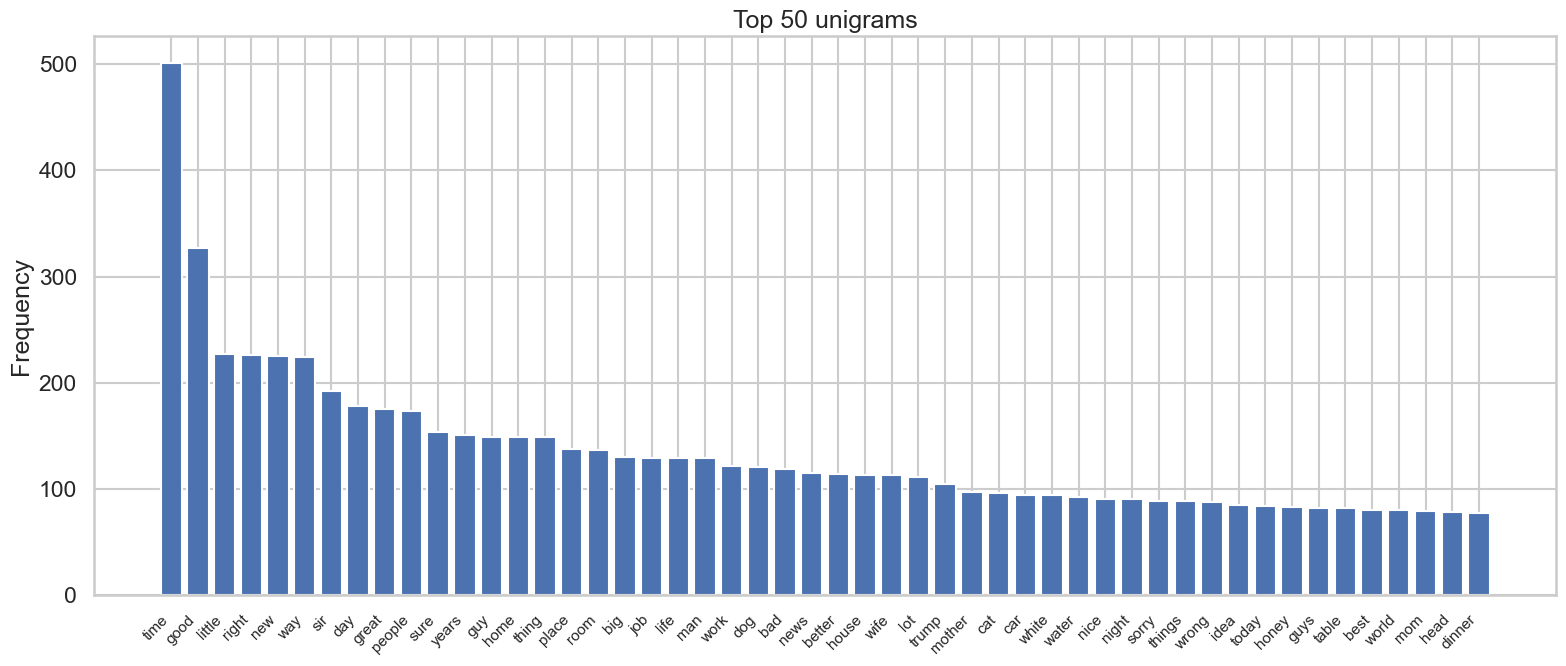

In [3]:
TOP_K = 50

top_captions = df_caption.groupby('contest_id', group_keys=False).apply(lambda x: x.nlargest(50, 'votes'))
    
top_captions_list = top_captions['caption'].dropna().astype(str).tolist()

vocab, counts = count_terms(top_captions_list)
top_vocab, top_counts = top_terms(vocab, counts)
plot_top_terms(top_vocab, top_counts)

We can see that the word `time` is by far the most frequent word, as it appears 500 times in the most funny captions. Most words do not give many information, but some statistics are interesting. For example, words to describe a man are quite frequent (`sir`, `guy`, `man`, `guys`), while words to describe a woman are less frequent (`wife`, `mother`, `mom`), and all of them describe the "role" (wife / mother) of the woman, and not the individual in general.

Also, we can see that the word `Trump` is the 30th most used word in caption. Thus, we will analyze whether this word is used only during a certain period of time, e.g. when Trump is president.

11156 captions containing the mention of trump.
235 captions ranked under 100 contain the mention of trump.


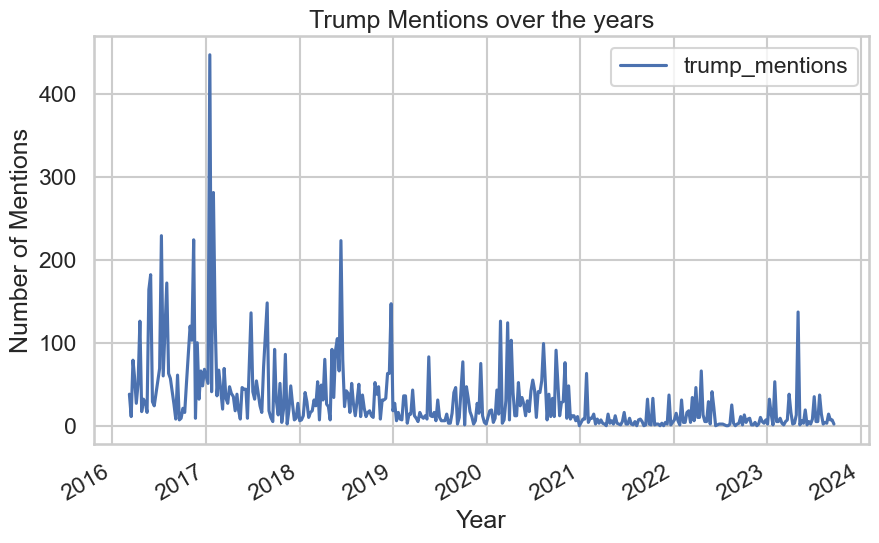

In [4]:
# at which frequency do captions mention Trump ?
caption_mentions(df_caption, 'trump')

Because the analysis about Trump's mentions' frequency of appearance gave us interesting results, we decided to visualize the word 'COVID' wit the same way, even if this word does not appear frequently according to the figure showing the top 50 unigrams.

The figure shows that Trump is mentioned frequently over time, and the frequency fluctuates by following a pattern. A massive surge in mentions is visible from 2016 to 2018 with a peak in early 2017, corresponding to Trump's presidential campaign and early presidency. Media and public attention were extremely high during this time. Then, after mid-2017, the mentions frequency shows a downward trend. This likely reflects a normalization effect, where Trump remained relevant but no longer dominated headlines as much as during the election and early administration. Around 2019-2020, moderate peaks appear, which are possibly tied to the 2020 election and a major political event. Following his departure from office, the mentions drop, even if he still apears occasionally. Finally Trump's mentions increase again mid-2023, where Trump announced his run for presidency again.

1125 captions containing the mention of virus.
10 captions ranked under 100 contain the mention of virus.


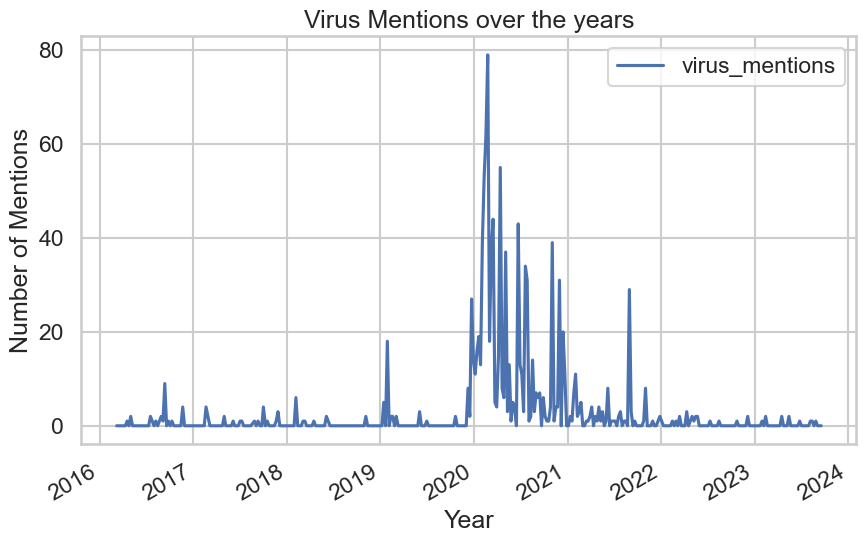

In [ ]:
caption_mentions(df_caption, 'virus')

89 captions containing the mention of ukraine.
0 captions ranked under 100 contain the mention of ukraine.


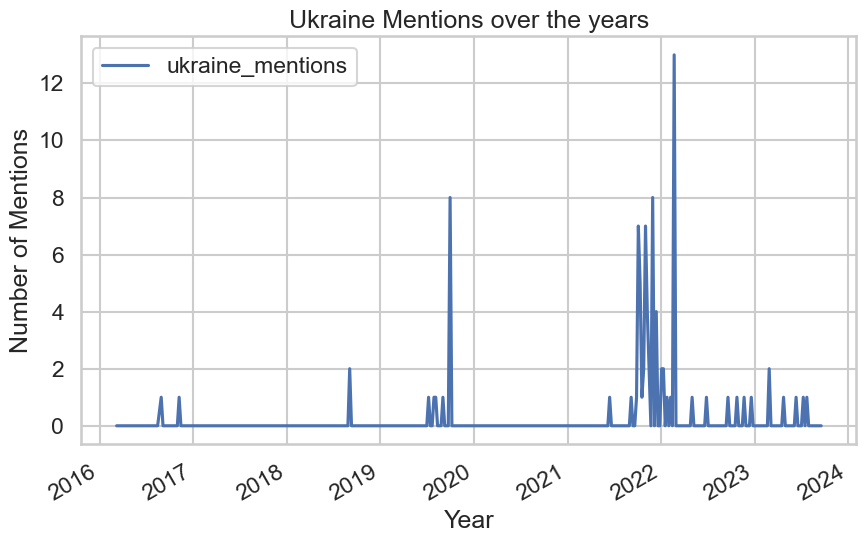

In [ ]:
# at which frequency do captions mention wars ?
caption_mentions(df_caption, 'ukraine')

In [5]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

concept_emb = model.encode("war conflict military invasion", normalize=True)
caption_embs = model.encode(df_caption['caption'].tolist(), normalize=True)

sims = util.cos_sim(concept_emb, caption_embs)[0]
df_caption['similarity'] = sims >0.35
df_caption

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ValueError: SentenceTransformer.encode() has been called with additional keyword arguments that this model does not use: ['normalize']. As per SentenceTransformer.get_model_kwargs(), this model does not accept any additional keyword arguments.

Because the analysis about Trump's mentions' frequency of appearance gave us interesting results, we decided to visualize the word 'COVID' wit the same way, even if this word does not appear frequently according to the figure showing the top 50 unigrams.

4615 captions containing the mention of covid.
22 captions ranked under 100 contain the mention of covid.


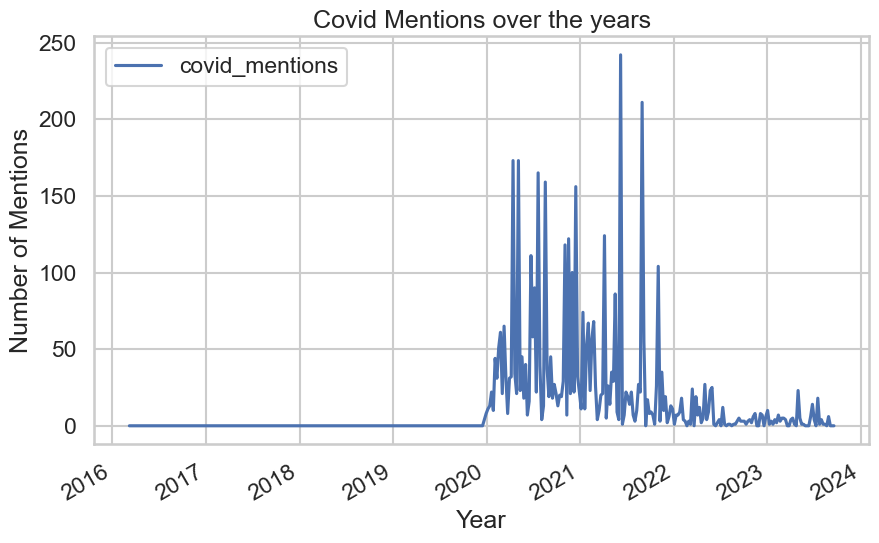

In [4]:
# at which frequency do captions mention COVID ?
caption_mentions(df_caption, 'covid')

1125 captions containing the mention of virus.
10 captions ranked under 100 contain the mention of virus.


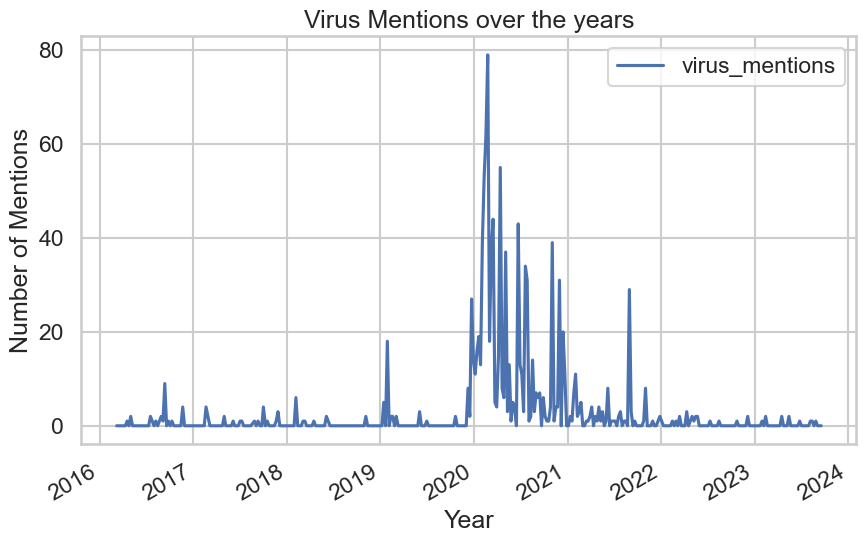

In [5]:
caption_mentions(df_caption, 'virus')

Here, the words mentioning the worldwide pandemic appear abruptly in 2020, at the same time as the pandemic, and the mentions kept going until late 2021, where the pandemic was slowly attenuating around the world.

The patterns observed in these two plots are consistent with the hypothesis that audience interest and humor evolve alongside political and global events.

## Captions mentionning men and mentionning women

In the section below, the word analysis is repeated using groups of related words rather than single ones. This helps to have less biased results. For example, using  word groups helps reduce the skew caused by using `men` to refer to humanity. 
Additionally, the word list for `men` is adjusted by removing any terms that overlap with the word list for `women`, since it contains the substring `men`.


In [ ]:
female_keywords = {"woman", "lady", "girl", "mom", "mother", "wife", "sister", "female"}
male_keywords   = {"man", "sir", "boy", "dad", "father", "husband", "brother", "male"}

mask_woman, mask_man = get_gender_masks_chunked(df_caption['caption'].tolist(), female_keywords, male_keywords,chunk_size=5000)

df_woman = df_caption[mask_woman]
df_man = df_caption[mask_man]

save_to_csv(df_woman, 'data/newyorker_caption_contest/df_woman.csv')
save_to_csv(df_man, 'data/newyorker_caption_contest/df_man.csv')

In [3]:
df_man = pd.read_csv('data/newyorker_caption_contest/df_man.csv')
df_woman = pd.read_csv('data/newyorker_caption_contest/df_woman.csv')

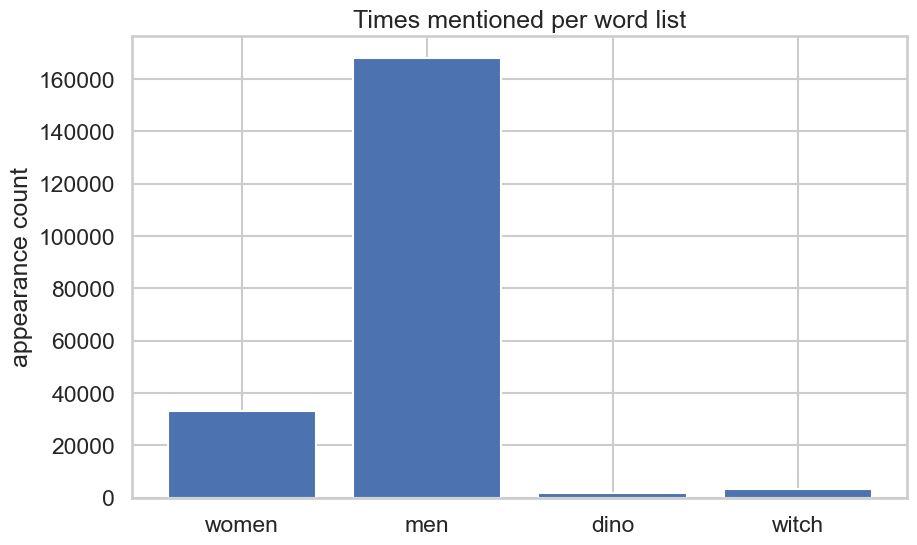

In [4]:
#plot the counts of the word list for all the data together as a boxplot
countdict = {
  "women": "women|woman|girl|mother|wife|mom|lady",
  "men": "men|man|boy|father|husband|sir|guy|dad",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "onlywomen": "women|woman"
  }

counts = do_counts(df_caption['caption'].copy(), countdict)

fig, ax = plt.subplots()
words = ['women',  'men', 'dino', 'witch'] #think about substracting women from men!!!!
counts[1] = counts[1]- counts[4]
ax.bar(words, counts[:4])
ax.set_ylabel('appearance count')
ax.set_title('Times mentioned per word list')
plt.show()

The results are shocking. Even in an unpolitical caption contest that probably tries to have an equal amount of genders represented, there is a big gap between mentions of women and men.
Moreover, when we check the captions and images individually, we can notice that there is almost never a women alone in a picture (unless it is a witch).

Thus, the Bechdel test, usually used for movies, applies also in cartoons:
- The *cartoon* has to have at least two women in it,
- who talk to each other,
- about something other than a man.

However, this wasn't observed...

source: https://en.wikipedia.org/wiki/Bechdel_test (24.11.25)

In [17]:
###Analyze the mentions over time
countdict = {
  "W": "women|woman",
  "men": "men|man|boy|father|husband|sir|guy",
  "women": "women|woman|girl|mother|wife",
  "trump": "trump|donald|president",
  "climat change": "climat|friday for future|FFF|school strike|flood|drougth|co2|extreme weather|sustainability|greehouse|deforestation|ecology|ipcc|fossil fuel|wild fire|ecology",
  "covid" : "covid|virus|pandemic|mask"
}

#find all IDs:
ids = np.array(df_caption['contest_id'].copy().drop_duplicates())
per_contest = []
votes = []
funny = []
not_funny = []
somewhat_funny = []

for i in range(len(ids)):
    df_ID = df_caption[df_caption['contest_id'] == ids[i]]
    per_contest.append(do_counts(df_ID['caption'].copy(), countdict))
    votes.append(df_ID['votes'].sum())
    funny.append(df_ID['funny'].sum())
    not_funny.append(df_ID['not_funny'].sum())
    somewhat_funny.append(df_ID['somewhat_funny'].sum())
per_contest = np.array(per_contest)

df_vc = pd.DataFrame(per_contest, columns=["w", "men", "women", "trump", "climat", "covid"])
df_vc['votes'] = votes
df_vc['men'] = df_vc["men"]-df_vc["w"]
df_vc['contest_ids'] = ids
df_vc['funny'] = funny
df_vc['not_funny'] = not_funny
df_vc['somewhat_funny'] = somewhat_funny

df_vc = df_vc.drop(["w"], axis=1)

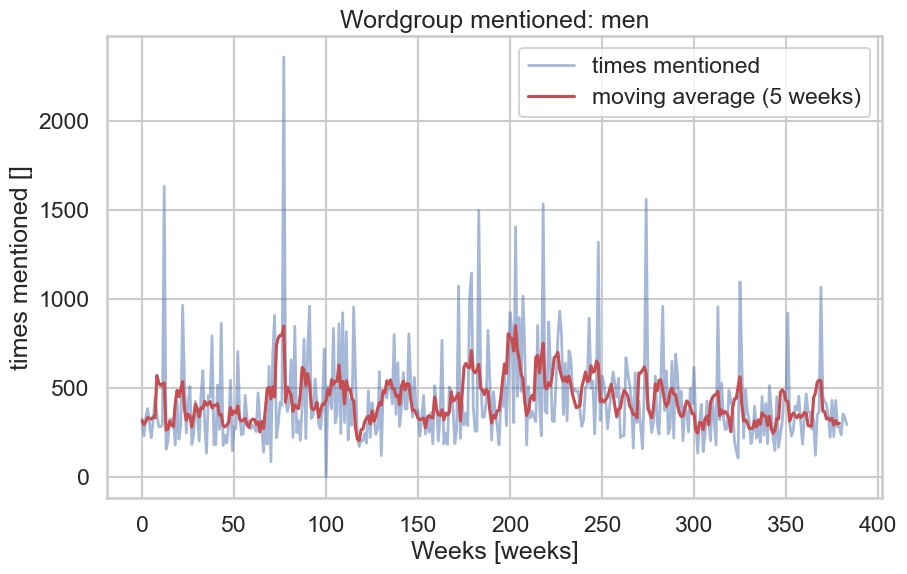

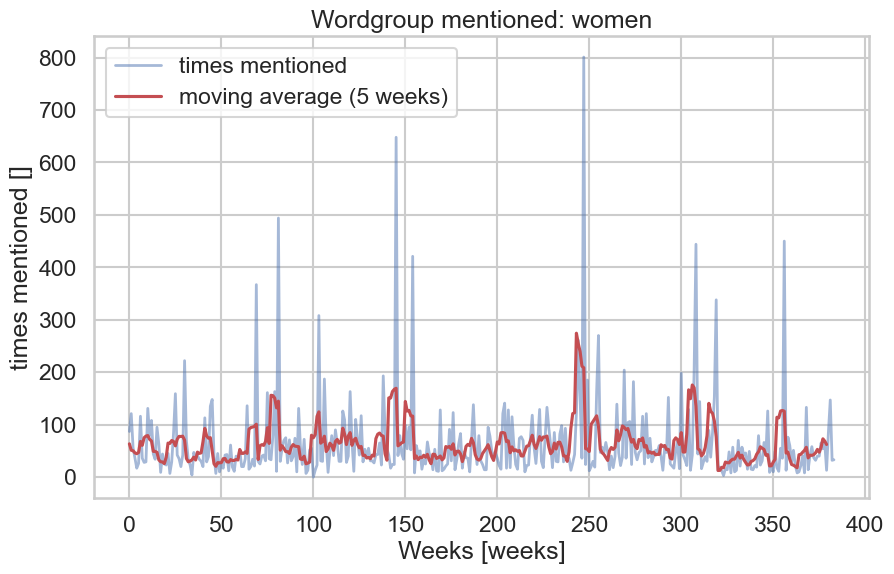

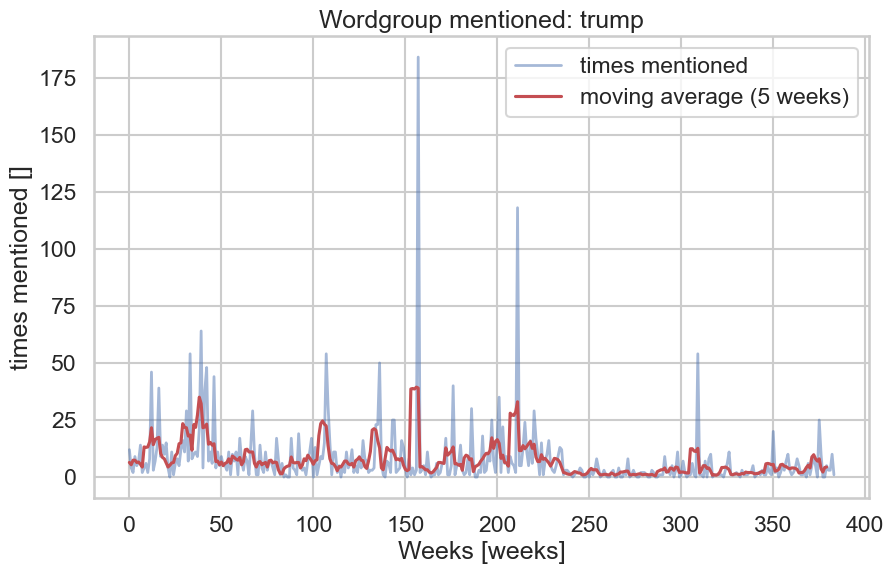

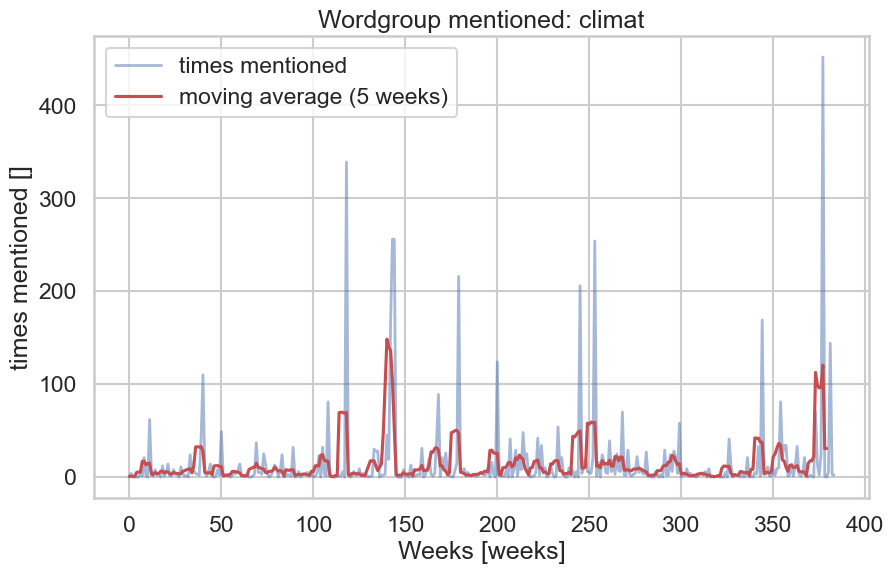

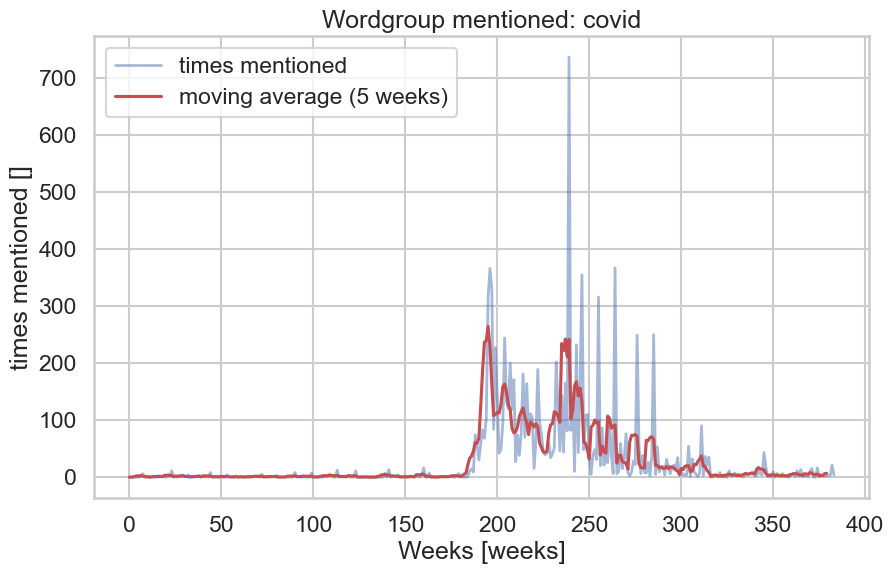

In [18]:
words = ["men", "women", "trump", "climat", "covid"]
c = np.array(df_vc[words])

for i in range(0,len(c[0,:])):
    Y1 = c[:,i]
    Y2 = moving_average(Y1, 5)
    plt.plot(np.arange(len(Y1)), Y1,linestyle='-', linewidth=2,alpha=.5)
    plt.plot(np.arange(len(Y2)), Y2,color='r')
    plt.title('Wordgroup mentioned: '+words[i])
    plt.xlabel('Weeks [weeks]')
    plt.ylabel('times mentioned []')
    plt.legend(['times mentioned', 'moving average (5 weeks)'])
    plt.show()

When analyzing the frequency of observed word groups over time, there is not a lot of information visible. The changes in cartoons are to big which creates a lot of noise. Therefore, a moving average filter for 5 weeks (in red) is applied to see the developement over time clearer.

For the word groups `men` and `women`, no dynamic over time can be observed visually.
For the word group `trump`, on the other hand, a reduction of use is to be observed. After week 230 - this is around when Donald Trump was elected president - the words for `trump` including the word `president` are a lot less used.

### Analysis focused on the user interactions (likes/dislikes)

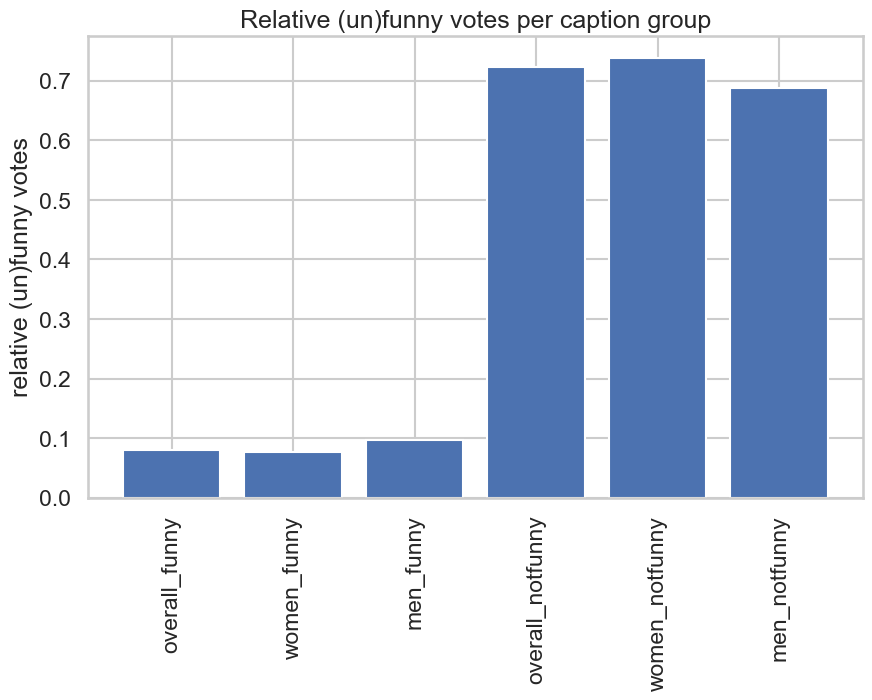

In [19]:
df_vc_sorted_w = df_vc.sort_values(by='women', ascending=False).head(20).copy()
df_vc_sorted_m = df_vc.sort_values(by='men', ascending=False).head(20).copy()

mean_women_votes = df_vc_sorted_w['votes'].mean()
mean_men_votes = df_vc_sorted_m['votes'].mean()

mean_women_funny = df_vc_sorted_w['funny'].mean()
mean_men_funny= df_vc_sorted_m['funny'].mean()

mean_women_notfunny = df_vc_sorted_w['not_funny'].mean()
mean_men_notfunny= df_vc_sorted_m['not_funny'].mean()

relative_women_funny = mean_women_funny / mean_women_votes
relative_men_funny= mean_men_funny / mean_men_votes

mean_overall_funny = df_caption['funny'].mean()
mean_overall_notfunny = df_caption['not_funny'].mean()
mean_overall_votes = df_caption['votes'].mean()

relative_overall_funny = mean_overall_funny/mean_overall_votes
relative_overall_notfunny = mean_overall_notfunny / mean_overall_votes

relative_women_notfunny = mean_women_notfunny / mean_men_votes
relative_men_notfunny= mean_men_notfunny / mean_men_votes

labels = ['overall_funny', 'women_funny', 'men_funny','overall_notfunny', 'women_notfunny', 'men_notfunny']
relatives = [relative_overall_funny, relative_women_funny, relative_men_funny,relative_overall_notfunny, relative_women_notfunny, relative_men_notfunny]
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.ylabel('relative (un)funny votes')
plt.title('Relative (un)funny votes per caption group')
plt.bar(labels, relatives)
plt.show()

The idea was to analyze if cartoons and captions that have more "men" or "women" mentioned are more controversal (create more interactions in terms of likes or dislikes). For this analysis, the top cartoons with the most "women" and the most "men" word group appearences are checked for their relative funny and unfunny count.

This is additionally, compared to the average count in order to see any anormaly compared to this. Visually, it can be observed that the wordgoups for "women" have lower values in funny and not funny. This can be just an error, or it can mean that the captions and cartoons of this wordgroup are just generating less interaction (positive and negative).

Caption Classification by Event Groups


In [4]:
WORD_GROUPS = {
    "covid": (
        "covid", "coronavirus", "pandemic", "virus", "quarantine",
        "lockdown", "vaccine", "mask", "outbreak", "immunity",
        "testing", "symptoms", "healthcare", "hygiene",
        "sanitizer", "ventilator", "distance", "social distancing",
        "variant", "delta", "omicron",
    ),
    "war": (
        "war", "conflict", "invasion", "attack", "battle",
        "military", "bombing", "troops", "soldier", "army", "navy",
        "airforce", "weapon", "missile", "siege", "occupation",
    ),
    "trump": (
        "trump", "donald", "president trump", "trump election", "politics", "political",
        "white house", "impeachment", "gop", "republican",
        "democrat", "biden",
    ),
    "climate": (
        "climate", "climate change", "global warming", "climate crisis",
        "environment", "environmental", "carbon", "emissions", "warming",
        "sustainability", "sustainable", "renewable", "fossil fuels",
    ),
}

def classify_caption_by_groups(caption, word_groups):
    """
    Check which word groups are present in a caption.
    """
    
    #tokenisation
    tokens = set(re.findall(r'[a-z]+', caption.lower()))
    found_groups = []
    
    for group_name, keywords in word_groups.items():
        normalized_keywords = set()
        for kw in keywords:
            normalized_keywords.update(re.findall(r'[a-z]+', kw.lower()))
        
        if tokens & normalized_keywords:
            found_groups.append(group_name)
    
    return found_groups

In [5]:
df_man['event_groups'] = df_man['caption'].apply(lambda cap: classify_caption_by_groups(cap, WORD_GROUPS))
df_woman['event_groups'] = df_woman['caption'].apply(lambda cap: classify_caption_by_groups(cap, WORD_GROUPS))

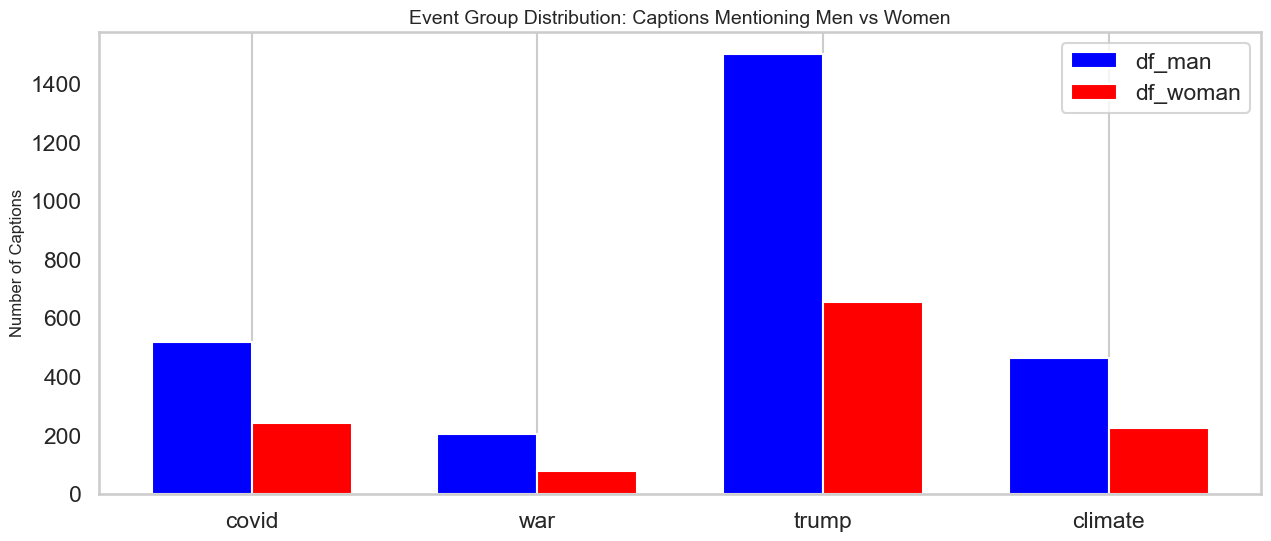

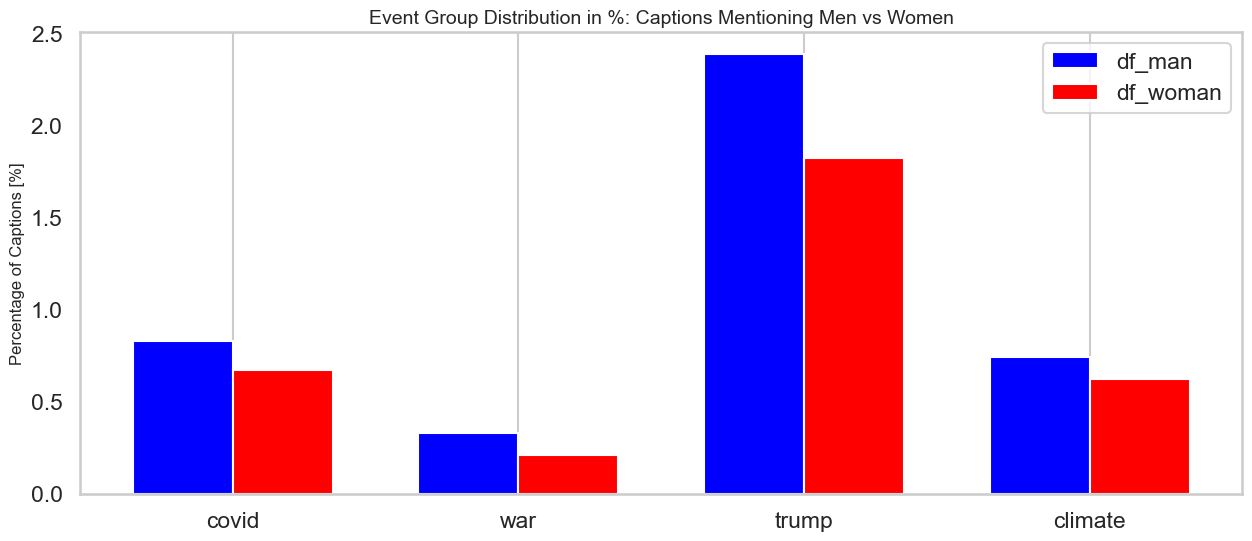

In [6]:
all_groups = list(WORD_GROUPS.keys())

counts_man = {}
counts_woman = {}

for group in all_groups:
    counts_man[group] = df_man['event_groups'].apply(
        lambda x: group in x if isinstance(x, list) else x == group).sum()
    
    counts_woman[group] = df_woman['event_groups'].apply(
        lambda x: group in x if isinstance(x, list) else x == group).sum()

# Comparison dataframe
comparison_df = pd.DataFrame({'df_man': counts_man,
                              'df_woman': counts_woman})

# Calculate percentages
total_man = len(df_man)
total_woman = len(df_woman)
comparison_pct = pd.DataFrame({'df_man': (comparison_df['df_man'] / total_man * 100).round(2),
                               'df_woman': (comparison_df['df_woman'] / total_woman * 100).round(2)})

# Plots
fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(all_groups))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['df_man'], width, label='df_man', color='blue')
bars2 = ax.bar(x + width/2, comparison_df['df_woman'], width, label='df_woman', color='red')

ax.set_ylabel('Number of Captions', fontsize=12)
ax.set_title('Event Group Distribution: Captions Mentioning Men vs Women', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(all_groups)
ax.legend()
ax.grid(axis='y')
plt.show()


fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(all_groups))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_pct['df_man'], width, label='df_man', color='blue')
bars2 = ax.bar(x + width/2, comparison_pct['df_woman'], width, label='df_woman', color='red')

ax.set_ylabel('Percentage of Captions [%]', fontsize=12)
ax.set_title('Event Group Distribution in %: Captions Mentioning Men vs Women', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(all_groups)
ax.legend()
ax.grid(axis='y')
plt.show()

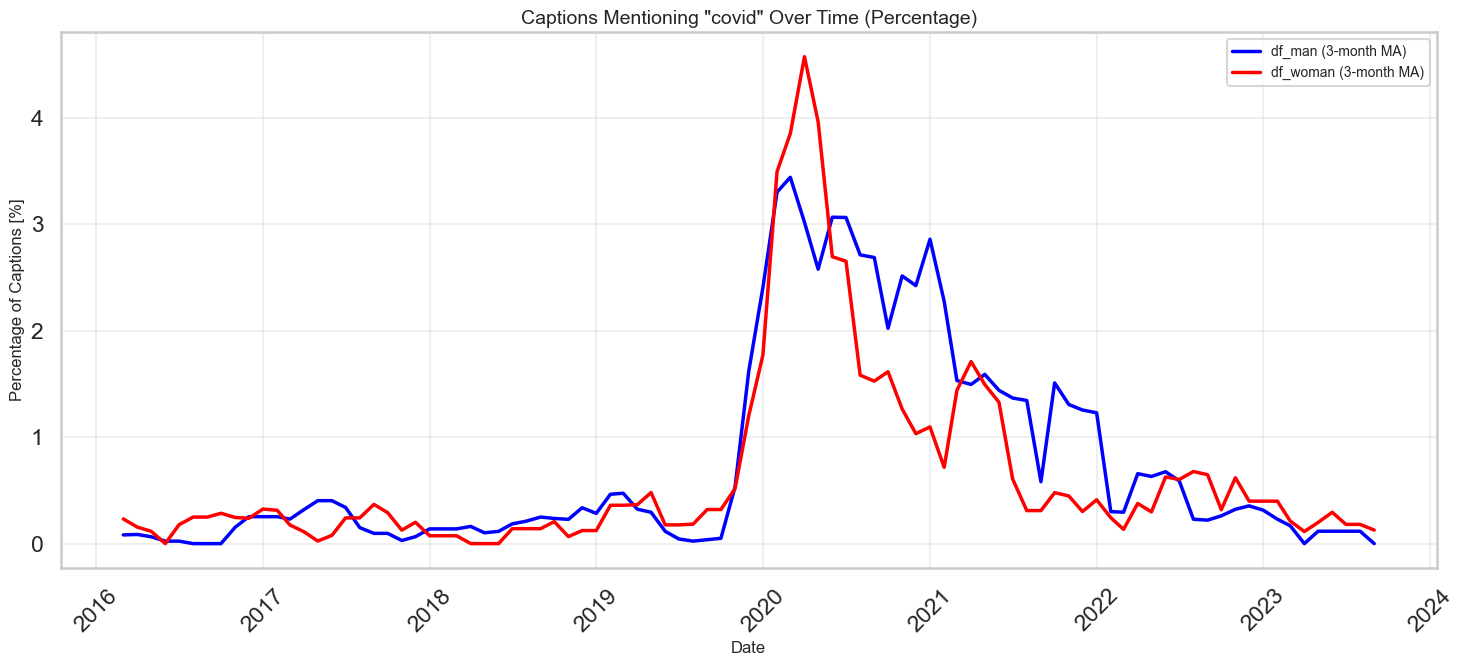

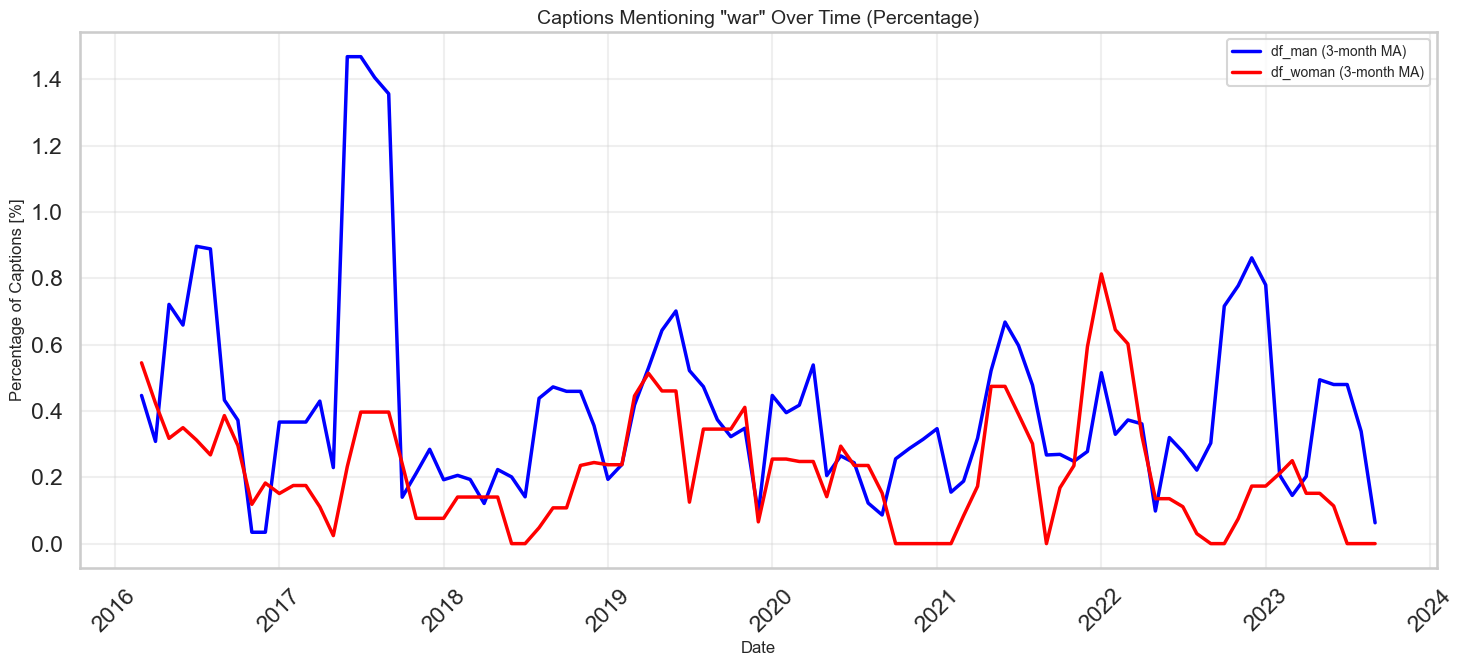

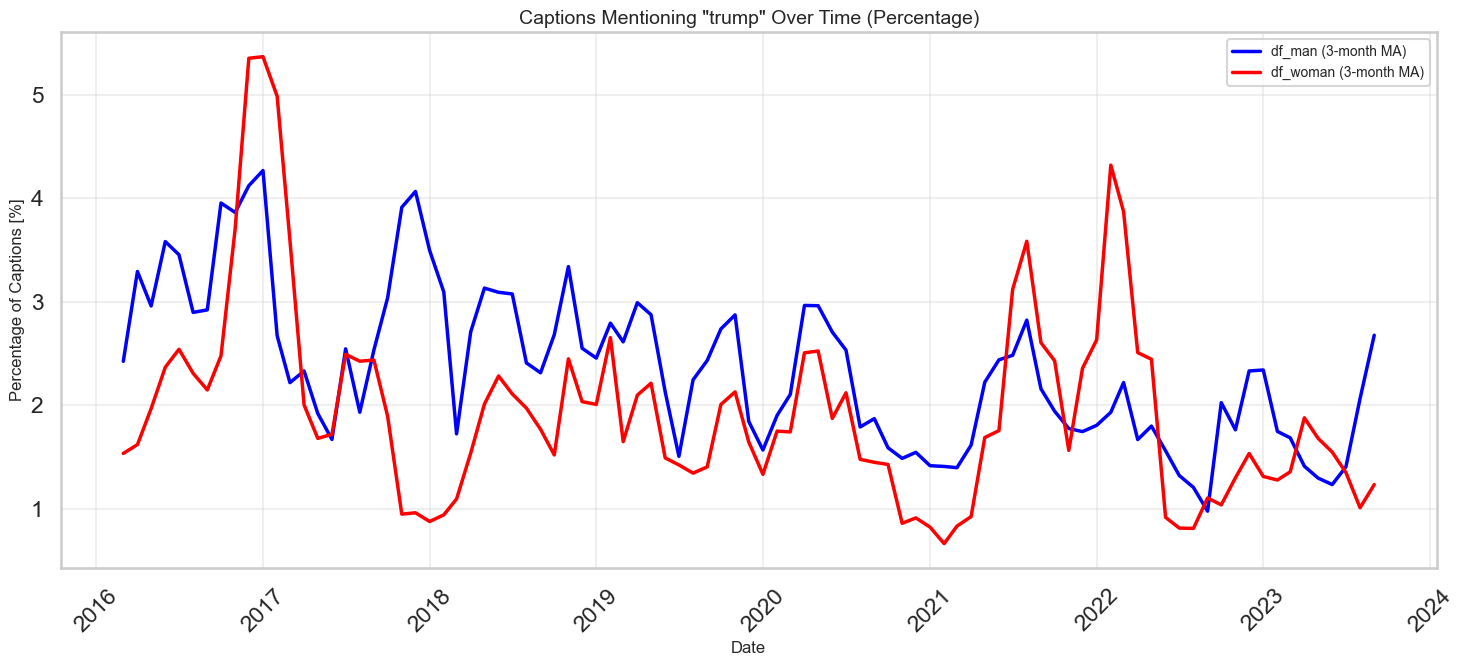

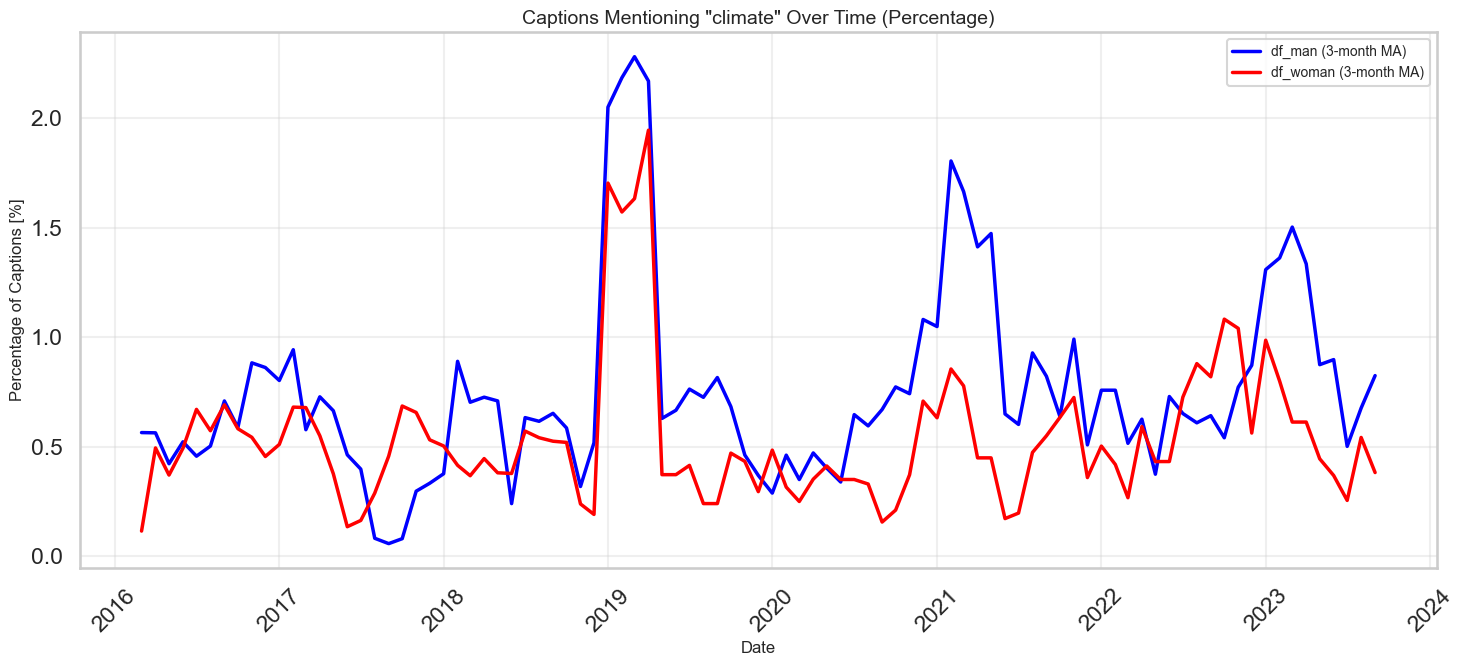

In [11]:
# Plot number of captions with each event group over time (counts and percentages with moving averages)
# Add date column to df_man and df_woman if not already present
df_man['date'] = pd.to_datetime(df_man['date'], errors='coerce')
df_woman['date'] = pd.to_datetime(df_woman['date'], errors='coerce')

# Create monthly time series for each event group, with df_man and df_woman on same plot
for group in all_groups:
    # df_man time series
    monthly_counts_man = []
    monthly_pcts_man = []
    monthly_dates_man = []
    for date, group_data in df_man.dropna(subset=['date']).groupby(df_man['date'].dt.to_period('M')):
        count = group_data['event_groups'].apply(
            lambda x: (group in x if isinstance(x, list) else x == group) if group != 'none' else (x == 0 or (isinstance(x, list) and len(x) == 0))
        ).sum()
        pct = (count / len(group_data)) * 100
        monthly_counts_man.append(count)
        monthly_pcts_man.append(pct)
        monthly_dates_man.append(date.to_timestamp())
    
    # df_woman time series
    monthly_counts_woman = []
    monthly_pcts_woman = []
    monthly_dates_woman = []
    for date, group_data in df_woman.dropna(subset=['date']).groupby(df_woman['date'].dt.to_period('M')):
        count = group_data['event_groups'].apply(
            lambda x: (group in x if isinstance(x, list) else x == group) if group != 'none' else (x == 0 or (isinstance(x, list) and len(x) == 0))
        ).sum()
        pct = (count / len(group_data)) * 100
        monthly_counts_woman.append(count)
        monthly_pcts_woman.append(pct)
        monthly_dates_woman.append(date.to_timestamp())
    # Calculate moving averages (3-month window)
    ma_counts_man = pd.Series(monthly_counts_man).rolling(window=4, center=True, min_periods=1).mean()
    ma_counts_woman = pd.Series(monthly_counts_woman).rolling(window=4, center=True, min_periods=1).mean()
    ma_pcts_man = pd.Series(monthly_pcts_man).rolling(window=4, center=True, min_periods=1).mean()
    ma_pcts_woman = pd.Series(monthly_pcts_woman).rolling(window=4, center=True, min_periods=1).mean()
    
    # Plot counts
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Plot percentages
    #ax.plot(monthly_dates_man, monthly_pcts_man, marker='o', linewidth=1, markersize=4, label='df_man (raw)', color='blue', alpha=0.5)
    ax.plot(monthly_dates_man, ma_pcts_man, linewidth=2.5, label='df_man (3-month MA)', color='blue')
    #ax.plot(monthly_dates_woman, monthly_pcts_woman, marker='s', linewidth=1, markersize=4, label='df_woman (raw)', color='red', alpha=0.5)
    ax.plot(monthly_dates_woman, ma_pcts_woman, linewidth=2.5, label='df_woman (3-month MA)', color='red')
    ax.set_title(f'Captions Mentioning "{group}" Over Time (Percentage)', fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Percentage of Captions [%]', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Google trends ##
This section aims to correlate Google search interest with our humor dataset to see whether public attention to certain topics aligns with shifts in humor themes. We use the weekly Google Trends data stored in data/GoogleTrends and compare it with our own time series of humor types to analyze how closely real-world events and humor evolution are connected over time. £

### Token Frequency Extraction ###
This cell loads the New Yorker contest data, tokenizes the text using NLTK, removes stopwords, counts word frequencies for each text field, and saves the results as CSV files in data/GoogleTrends/frequent_words.

In [14]:
EN_STOP = set(stopwords.words('english'))

# ---- config ----
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
OUTDIR = pathlib.Path("data/GoogleTrends/frequent_words")

# Fallback regex tokenizer (letters only, >=3 chars)
TOKEN_RE = re.compile(r"[A-Za-z]{3,}")

def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    # basic cleanup: strip; drop empty
    out = [t.strip() for t in out if isinstance(t, str) and t.strip()]
    return out

def tokenize_lower(text: str):
    """Prefer NLTK word_tokenize; fallback to regex if unavailable."""
    if word_tokenize is not None:
        try:
            return [w.lower() for w in word_tokenize(text)]
        except LookupError:
            # If punkt/punkt_tab still missing for some reason, fallback
            return [w.lower() for w in TOKEN_RE.findall(text)]
    else:
        return [w.lower() for w in TOKEN_RE.findall(text)]

def count_tokens_nltk(texts):
    c = Counter()
    for t in texts:
        tokens = tokenize_lower(t)
        # keep only alphabetic tokens, >=3 chars, not in stopwords
        filtered = [w for w in tokens if w.isalpha() and len(w) >= 3 and w not in EN_STOP]
        c.update(filtered)
    return c

def save_counts_csv(counter: Counter, out_path: pathlib.Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["token", "count"])
        for tok, freq in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])):
            w.writerow([tok, freq])

# ---- run ----
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    counts = count_tokens_nltk(texts)
    outfile = OUTDIR / f"{field}__unigrams_nltk.csv"
    save_counts_csv(counts, outfile)


### Visualize the frequency ###
Loads the contest records, extracts each text field, vectorizes with CountVectorizer (English stopwords, alphabetic tokens ≥3 chars, NGRAM_RANGE), sums term counts, picks the top TOP_K, and plots a bar chart per field.

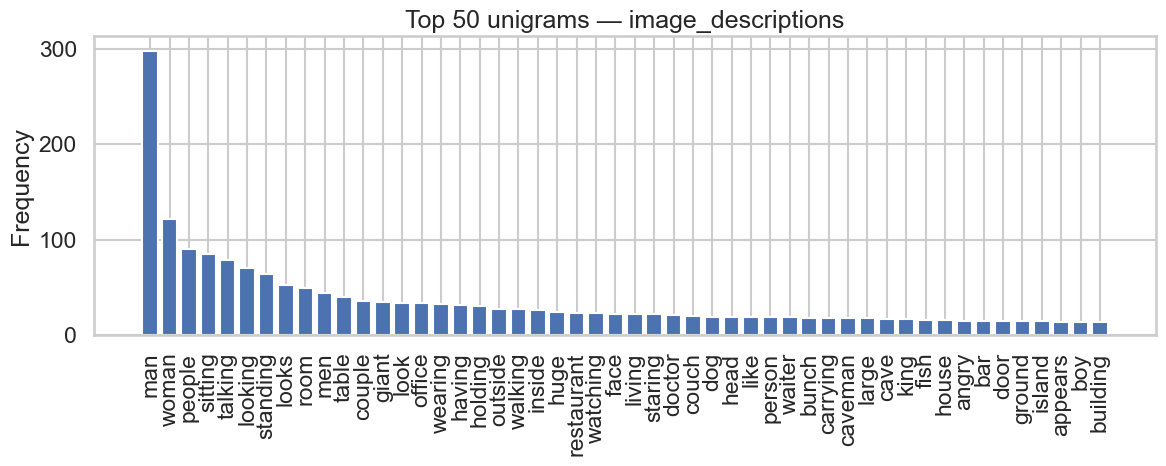

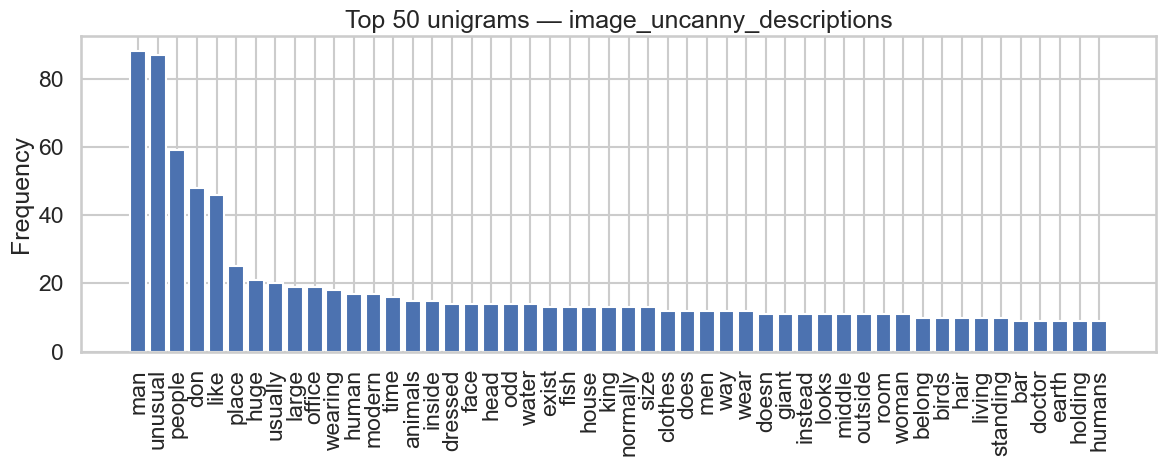

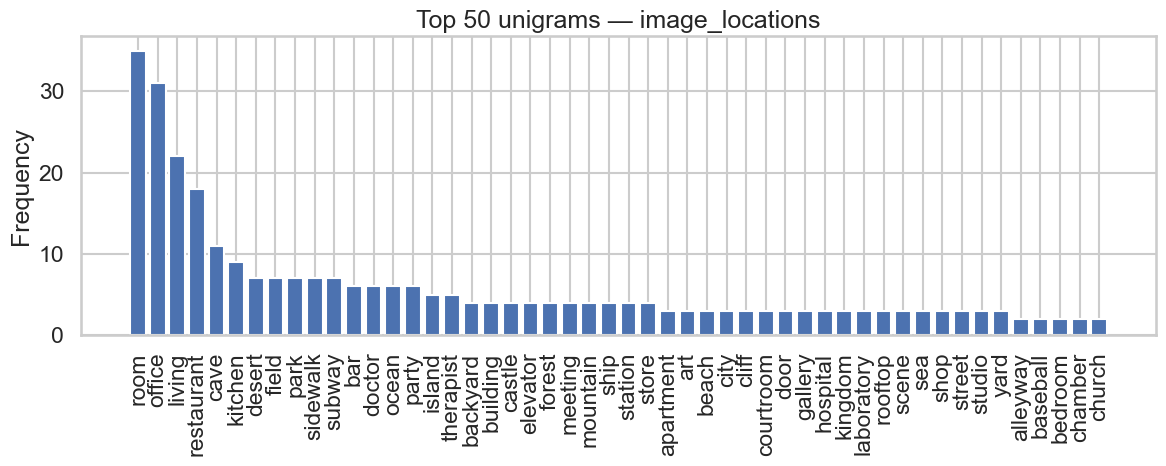

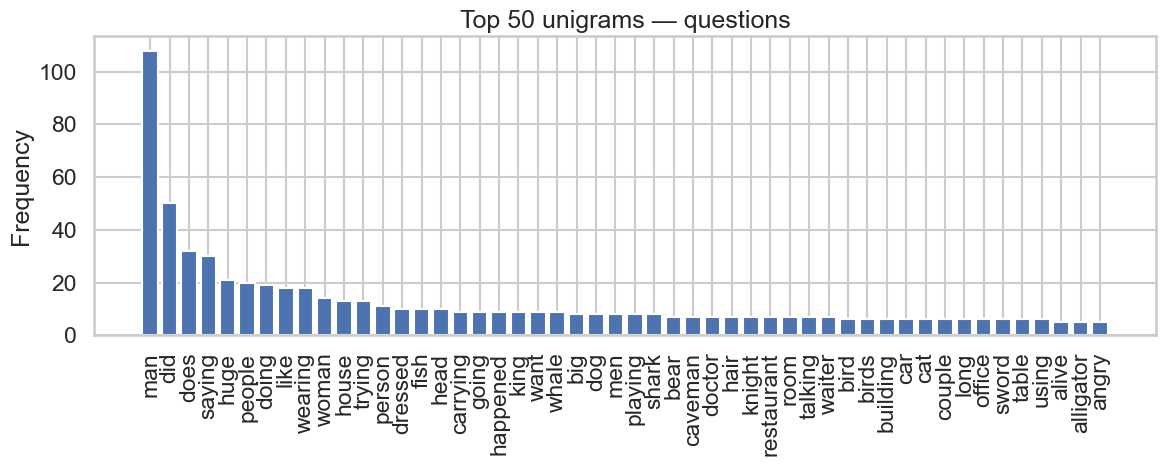

In [ ]:
for field in FIELDS:
    texts = collect_texts(records, field)
    if not texts:
        print(f"[{field}] No texts found, skipping.")
        continue

    vectorizer = CountVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        ngram_range=NGRAM_RANGE
    )
    X = vectorizer.fit_transform(texts)               # sparse [n_docs, n_vocab]
    counts = np.asarray(X.sum(axis=0)).ravel()        # total counts per vocab term
    vocab = np.array(vectorizer.get_feature_names_out())

    # sort by frequency desc, then term asc
    order = np.lexsort((vocab, -counts))
    top_idx = order[:TOP_K]
    top_terms = vocab[top_idx]
    top_counts = counts[top_idx]

    # Plot one figure per field
    plt.figure(figsize=(12, 5))
    plt.bar(top_terms, top_counts)
    plt.xticks(rotation=90)
    ngram_label = "unigrams" if NGRAM_RANGE == (1,1) else f"{NGRAM_RANGE[0]}-{NGRAM_RANGE[1]}-grams"
    plt.title(f"Top {TOP_K} {ngram_label} — {field}")
    plt.ylabel("Frequency")
    plt.tight_layout()
        plt.show()

# Quantitative summary: compare mean interest before/during/after pandemic
pre_covid = group_series.loc["2016-03":"2020-02"].mean()
covid = group_series.loc["2020-03":"2021-12"].mean()
post_covid = group_series.loc["2022-01":"2023-09"].mean()

summary = pd.DataFrame({"pre_covid": pre_covid, "covid": covid, "post_covid": post_covid})
print("\nAverage interest levels:")
display(summary)


## Topic detection on `df_caption` -> peut-être pas à garder / à voir

This cell group preprocesses captions, trains an LDA model on the captions, and attaches topic labels and probabilities to each row while preserving `caption`, `date`, and `rank`.
If captions are short, consider grouping by week/month or using embedding-based clustering (BERTopic or sentence-transformers + HDBSCAN).

In [3]:
# Parameters - tune as needed
NUM_TOPICS = 8
MIN_WORD_COUNT = 3
MAX_DOC_FREQ = 0.5
BIGRAM_MIN_COUNT = 5
LDA_PASSES = 10

df_topics = df_caption[['caption','date','rank']].copy()
df_topics['caption'] = df_topics['caption'].astype(str).fillna('')
df_topics['date'] = pd.to_datetime(df_topics['date'], errors='coerce')

nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])

def preprocess_captions(captions, batch_size=200):
    out = []
    for doc in nlp.pipe(list(captions), batch_size=batch_size):
        toks = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop and len(token.lemma_)>2]
        out.append(toks)
    return out

print('Preprocessing captions...')
docs = preprocess_captions(df_topics['caption'], batch_size=200)
print('Processed', len(docs), 'documents')

# Build bigrams and dictionary
bigram = Phrases(docs, min_count=BIGRAM_MIN_COUNT, threshold=10)
docs = [bigram[doc] for doc in docs]
dictionary = Dictionary(docs)
dictionary.filter_extremes(no_below=MIN_WORD_COUNT, no_above=MAX_DOC_FREQ)
print('Vocabulary size after filtering:', len(dictionary))

corpus = [dictionary.doc2bow(doc) for doc in docs]
empty_docs = sum(1 for b in corpus if len(b)==0)
print(f'Corpus ready. {empty_docs} documents became empty after filtering.')

Preprocessing captions...
Processed 2263048 documents
Processed 2263048 documents
Vocabulary size after filtering: 66512
Vocabulary size after filtering: 66512
Corpus ready. 19080 documents became empty after filtering.
Corpus ready. 19080 documents became empty after filtering.


In [4]:
# Train LDA and attach topic assignments to df_topics
from gensim.models.ldamulticore import LdaMulticore

print('Training LDA...')
lda = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=NUM_TOPICS, workers=2, passes=LDA_PASSES, random_state=42)

# show top words per topic
for i in range(NUM_TOPICS):
    terms = [w for w,_ in lda.show_topic(i, topn=8)]
    print(f'Topic {i}:', ', '.join(terms))

# Assign topic and probability per doc
topic_assignments = []
for bow in corpus:
    if len(bow)==0:
        topic_assignments.append((-1, 0.0))
    else:
        tdist = lda.get_document_topics(bow, minimum_probability=0.0)
        top_topic, top_prob = max(tdist, key=lambda x:x[1])
        topic_assignments.append((int(top_topic), float(top_prob)))

df_topics['topic'] = [t for t,p in topic_assignments]
df_topics['topic_prob'] = [p for t,p in topic_assignments]

print('Sample assignments:')
display(df_topics.head(10))

# Quick counts and monthly pivot
print('Topic counts:')
print(df_topics['topic'].value_counts(dropna=False))

df_topics['month'] = df_topics['date'].dt.to_period('M').astype(str)
pivot = (df_topics[df_topics['topic'] >= 0]
         .groupby(['month','topic'])
         .size()
         .reset_index(name='count')
         .pivot(index='month', columns='topic', values='count')
         .fillna(0)
         .sort_index())
print('Topic counts by month (first 10 rows):')
display(pivot.head(10))

# Save df_topics in the notebook namespace for later analysis
df_topics = df_topics.reset_index(drop=True)
df_topics

Training LDA...
Topic 0: say, right, mean, know, sure, head, want, worry
Topic 1: need, well, way, talk, play, help, place, man
Topic 2: time, good, ask, remember, minute, happen, fly, bad
Topic 3: wish, hear, leave, eat, take, see, guess, believe
Topic 4: tell, find, life, love, home, drink, know, peanut
Topic 5: think, work, try, big, people, day, say, actually
Topic 6: get, let, yes, great, pitch, know, yeah, run
Topic 7: like, look, feel, come, sorry, stop, wait, know
Topic 0: say, right, mean, know, sure, head, want, worry
Topic 1: need, well, way, talk, play, help, place, man
Topic 2: time, good, ask, remember, minute, happen, fly, bad
Topic 3: wish, hear, leave, eat, take, see, guess, believe
Topic 4: tell, find, life, love, home, drink, know, peanut
Topic 5: think, work, try, big, people, day, say, actually
Topic 6: get, let, yes, great, pitch, know, yeah, run
Topic 7: like, look, feel, come, sorry, stop, wait, know
Sample assignments:
Sample assignments:


,caption,date,rank,topic,topic_prob
0,I'm a congressman--obstruction is my job.,2016-03-07,0,1,0.282112
1,"I'm what they mean when they say, 'The middle ...",2016-03-07,1,6,0.425517
2,Does this suit make me look flat?,2016-03-07,2,4,0.531227
3,"When the right woman comes along, I'll know it.",2016-03-07,3,3,0.486827
4,"I used to lie in the gutter, but then I quit d...",2016-03-07,4,1,0.283202
5,"If you can meditate here, you can meditate any...",2016-03-07,5,2,0.707843
6,"Sorry for the inconvenience, I probably should...",2016-03-07,6,2,0.199168
7,I've decided to take it lying down.,2016-03-07,7,1,0.708325
8,Anyone who steps on me is out!,2016-03-07,8,5,0.562312
9,Guess I should have jumped from a few floors h...,2016-03-07,9,2,0.225013


Topic counts:
topic
 7    323374
 5    291036
 0    288945
 6    280546
 4    273542
 3    271183
 1    267567
 2    247775
-1     19080
Name: count, dtype: int64
Topic counts by month (first 10 rows):
Topic counts by month (first 10 rows):


topic,0,1,2,3,4,5,6,7
month,,,,,,,,
2016-03,1920,1960,1824,2132,1725,2352,1754,1952
2016-04,3050,2214,2862,2606,2728,2554,2644,3121
2016-05,2867,3006,3078,2885,3164,4345,2882,3359
2016-06,1018,758,920,922,842,1249,1165,1222
2016-07,2215,2211,2049,2242,2191,2319,2644,2367
2016-08,1738,1546,1372,1548,1833,1877,1460,1816
2016-09,2702,2305,2714,3485,2100,3153,2380,3056
2016-10,2201,1808,1866,2142,2519,2962,2221,2692
2016-11,3092,3058,2163,2578,2203,3213,2490,2952


,caption,date,rank,topic,topic_prob,month
0,I'm a congressman--obstruction is my job.,2016-03-07,0,1,0.282112,2016-03
1,"I'm what they mean when they say, 'The middle ...",2016-03-07,1,6,0.425517,2016-03
2,Does this suit make me look flat?,2016-03-07,2,4,0.531227,2016-03
3,"When the right woman comes along, I'll know it.",2016-03-07,3,3,0.486827,2016-03
4,"I used to lie in the gutter, but then I quit d...",2016-03-07,4,1,0.283202,2016-03
...,...,...,...,...,...,...
2263043,Looks like we took a wrong turn at the Hubble ...,2023-09-18,4953,7,0.347313,2023-09
2263044,Post-modern just doesn't do it for me.,2023-09-18,4954,5,0.561994,2023-09
2263045,How was I supposed to know they covered themse...,2023-09-18,4955,4,0.351431,2023-09
2263046,"No, they wanted us to teleport the giveaway ca...",2023-09-18,4956,3,0.281678,2023-09


In [ ]:
save_to_csv(df_topics, 'data/newyorker_caption_contest/df_topics.csv')

In [53]:
from empath import Empath
lexicon = Empath()

In [133]:
# Combined categories generated from existing Empath categories
combined_categories = {
    # -------------------------------------------------
    # Emotion / Affect / Sentiment
    "positive_emotion": ["joy", "cheerfulness", "contentment", "positive_emotion", "optimism", "zest", "affection", "love", "sympathy"],
    "negative_emotion": ["sadness", "anger", "fear", "disgust", "negative_emotion", "irritability", "pain", "suffering", "torment"],
    # -------------------------------------------------
    # Health & Body
    "health_related": ["health", "healing", "body", "exercise", "hygiene", "sleep", "medical_emergency", "disease", "illness", "injury", "death"],
    # -------------------------------------------------
    # Violence / Conflict / Crime / War
    "violence_conflict": ["violence", "war", "military", "crime", "terrorism", "kill", "fight", "prison", "conflict", "ukraine"],
    # -------------------------------------------------
    # Work / Economy / Money
    "economy_business": ["money", "business", "work", "office", "banking", "economics", "real_estate"],
    # -------------------------------------------------
    # Home / Lifestyle / Daily Life
    "home_lifestyle": ["home", "domestic_work", "cooking", "cleaning", "furniture", "family", "child", "friend"],
    # -------------------------------------------------
    # Environment
    "nature_environment": ["water", "plant", "animal", "forest", "weather", "beach", "temperature", "heat"],
    # -------------------------------------------------
    # Social Institutions / Politics / Government / Law / Power
    "politics_government": ["politics", "government", "law", "power", "justice", "order", "dominant_personality", "trump"],

}

In [134]:
grouped = df_topics.groupby('date')
df_topics['tokens'] = docs
categories = lexicon.cats.keys()

results = []
for date, group in grouped:
    all_tokens = []
    for tokens in group['tokens']:
        all_tokens.extend(tokens)
        
    text = " ".join(all_tokens)
    empath_features = lexicon.analyze(text,categories = categories)
    
    token_count = len(all_tokens)
    
    if token_count > 0:
        empath_features = {k: v / token_count for k, v in empath_features.items()}

    empath_features['date'] = date
    results.append(empath_features)

df_empath = pd.DataFrame(results)
df_empath["date"] = pd.to_datetime(df_empath["date"])
df_empath = df_empath.set_index("date").sort_index()

combined_features = pd.DataFrame(index=df_empath.index)


for new_cat, old_cats in combined_categories.items():
    existing = [c for c in old_cats if c in df_empath.columns]
    if existing:
        combined_features[new_cat] = df_empath[existing].sum(axis=1)
combined_features

,positive_emotion,negative_emotion,health_related,violence_conflict,economy_business,home_lifestyle,nature_environment,politics_government
date,,,,,,,,
2016-03-07,0.053580,0.063583,0.079137,0.033847,0.088249,0.039329,0.026105,0.027681
2016-03-14,0.033259,0.038401,0.066600,0.027370,0.099942,0.120345,0.025297,0.034005
2016-03-21,0.035024,0.041015,0.081663,0.023961,0.048900,0.060636,0.013570,0.025856
2016-03-27,0.038345,0.045432,0.048785,0.040433,0.183877,0.029803,0.008226,0.038724
2016-04-03,0.030608,0.046700,0.036291,0.041153,0.053752,0.032936,0.047590,0.031704
...,...,...,...,...,...,...,...,...
2023-08-21,0.025682,0.048091,0.030689,0.032722,0.161130,0.036886,0.020575,0.031433
2023-08-28,0.028710,0.062016,0.063720,0.034803,0.034700,0.093773,0.033254,0.023495
2023-09-04,0.046670,0.016693,0.031026,0.015732,0.214386,0.141147,0.051390,0.019839


<Figure size 1200x600 with 0 Axes>

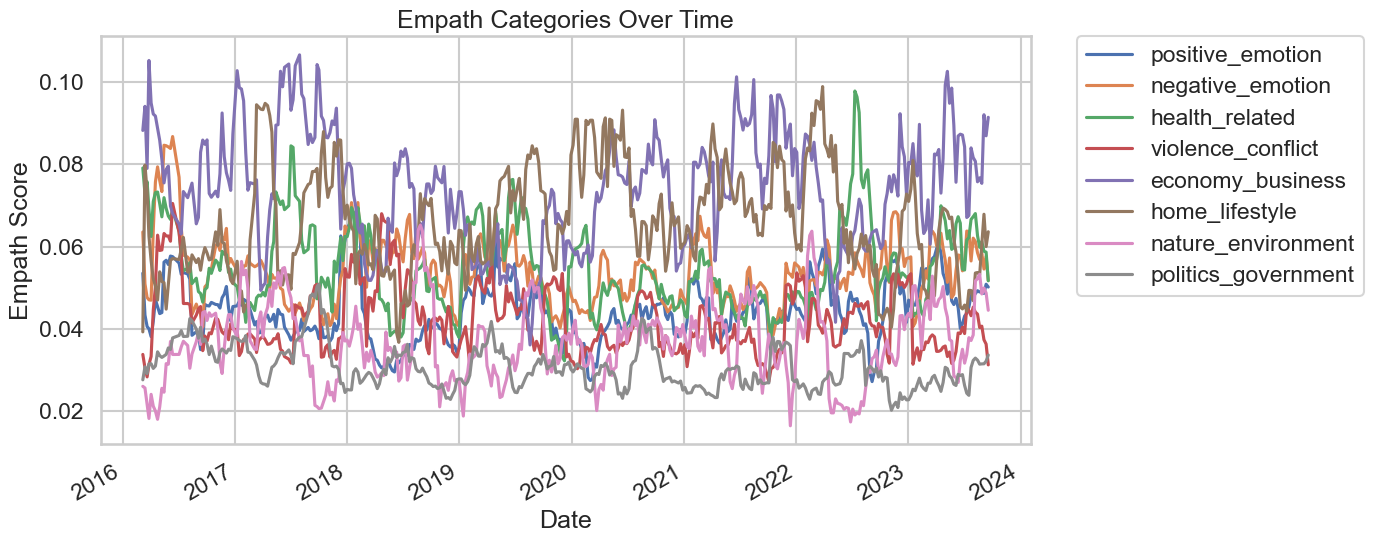

In [135]:
df_smoothed = combined_features.rolling(window=10, min_periods=1).mean()


plt.figure(figsize=(12,6))
df_smoothed.plot(figsize=(12,6))
plt.title("Empath Categories Over Time")
plt.xlabel("Date")
plt.ylabel("Empath Score")
plt.grid(True)
plt.legend(title="Category")
# place legend outside to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

<Figure size 1200x600 with 0 Axes>

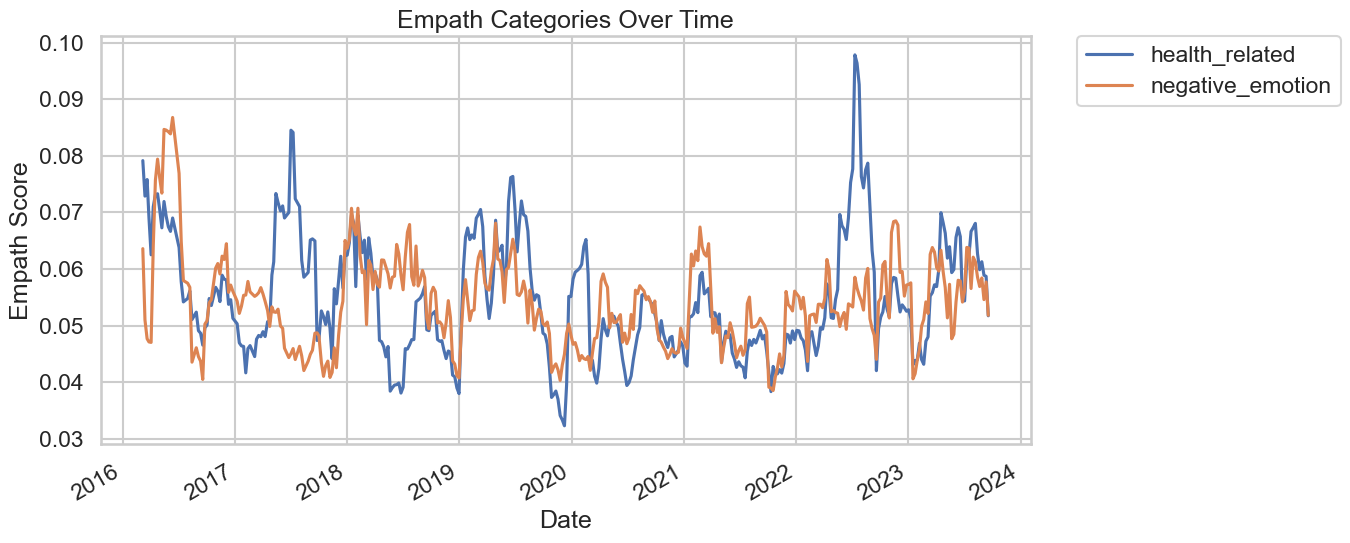

In [131]:
covid = df_smoothed[['health_related', 'negative_emotion']]


plt.figure(figsize=(12,6))
covid.plot(figsize=(12,6))
plt.title("Empath Categories Over Time")
plt.xlabel("Date")
plt.ylabel("Empath Score")
plt.grid(True)
plt.legend(title="Category")
# place legend outside to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()